# Gradient Boosting

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Part A - Gradient Boosting Regression

In [19]:
housing=fetch_california_housing(as_frame=True)
df=housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [20]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [21]:
X=df.drop(columns='MedHouseVal')
y=df['MedHouseVal']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)


### Train Baseline Model

In [22]:
gbr=GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42)
gbr.fit(X_train,y_train)
pred=gbr.predict(X_test)

print("MAE :",mean_absolute_error(y_test,pred))
print("RMSE:",mean_squared_error(y_test,pred)**0.5)
print("R2  :",r2_score(y_test,pred))


MAE : 0.3716425690425596
RMSE: 0.5422152016168362
R2  : 0.7756446042829697


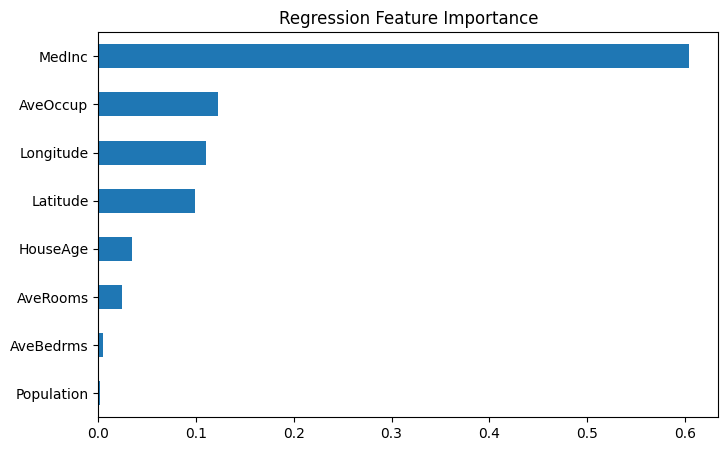

In [23]:
fi=pd.Series(gbr.feature_importances_,index=X.columns)
fi.sort_values().plot(kind='barh',figsize=(8,5))
plt.title("Regression Feature Importance")
plt.show()


### Hyperparameter Tuning

In [13]:
params={
'n_estimators':[100,200],
'learning_rate':[0.05,0.1],
'max_depth':[2,3]
}
grid=GridSearchCV(GradientBoostingRegressor(random_state=42),
                  params,cv=3,n_jobs=-1)
grid.fit(X_train,y_train)
print(grid.best_params_)
print(grid.best_score_)


{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
0.80582065878487


## Part B - Gradient Boosting Classification

In [25]:
cancer=load_breast_cancer(as_frame=True)
cdf=cancer.frame
print(cdf.shape)
cdf.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [15]:
X=cdf.drop(columns='target')
y=cdf['target']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42)


In [16]:
gbc=GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42)

gbc.fit(X_train,y_train)
pred=gbc.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print("\nConfusion Matrix\n",confusion_matrix(y_test,pred))
print("\nClassification Report\n")
print(classification_report(y_test,pred))


Accuracy: 0.956140350877193

Confusion Matrix
 [[38  4]
 [ 1 71]]

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



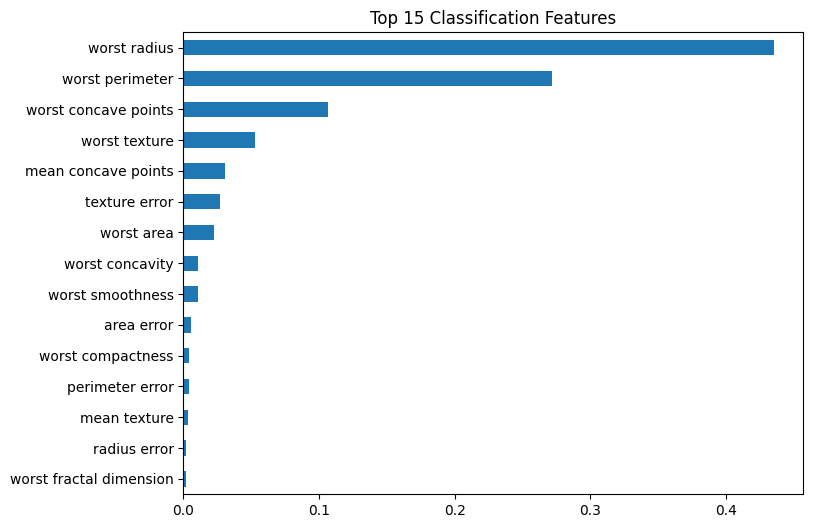

In [17]:
fi=pd.Series(gbc.feature_importances_,index=X.columns)
fi.nlargest(15).sort_values().plot(kind='barh',figsize=(8,6))
plt.title("Top 15 Classification Features")
plt.show()


## For more reference

1. Krish Naik: https://youtu.be/eEtEPdw2dck
2. Ranjan Sharma: https://youtu.be/0ARLObJJ3y4
3. Gate Smashers: https://youtu.be/vtOI7NgXMQQ